# Unit07 Example 05 - 熱板乾燥過程之乾燥面溫度計算（單變數非線性方程式求解）

本範例以**工業熱板乾燥（Hot-Air Drying）**的穩態操作為例，介紹如何利用 `scipy.optimize.root_scalar()` 求解**單變數非線性方程式**，並結合 Antoine 方程式計算飽和蒸氣壓，探討熱質傳耦合下的乾燥面溫度計算問題。

## 目標

- 建立乾燥面熱質平衡之**耦合非線性方程式** $f(T_s) = 0$
- 使用 **Antoine 方程式**計算水在不同溫度下的飽和蒸氣壓，並處理兩段 Antoine 係數的**分段函數**
- 比較 `brentq`、`bisect`、`newton` 等多種求解方法的收斂特性
- 計算恆率乾燥階段的**乾燥面溫度**與**乾燥速率**
- 進行**參數研究**：探討乾燥空氣溫度與相對濕度對乾燥性能的影響

---
### 0. 環境設定

In [10]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit07_Example_05'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit07'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit07
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit07\outputs\Unit07_Example_05
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit07\outputs\Unit07_Example_05\figs


---
### 1. 載入套件

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import root_scalar
import warnings
warnings.filterwarnings('ignore')

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
})

print("✓ 套件載入完成")
print(f"  numpy  版本: {np.__version__}")
import scipy
print(f"  scipy  版本: {scipy.__version__}")
import matplotlib
print(f"  matplotlib 版本: {matplotlib.__version__}")

✓ 套件載入完成
  numpy  版本: 1.23.5
  scipy  版本: 1.15.2
  matplotlib 版本: 3.10.8


---
### 2. 問題設定

**乾燥系統說明**

在工業乾燥操作的**恆率乾燥（Constant-Rate Drying）**階段，濕固體表面維持充分潤濕狀態，熱與質傳的速率共同決定乾燥面的穩態溫度 $T_s$ （即「濕球溫度」相關概念）。

**熱質量平衡（Heat-Mass Balance at the Drying Surface）：**

$$
h (T_{air} - T_s) = \lambda \cdot k_y \cdot (Y_s(T_s) - Y_{air})
$$

| 符號 | 說明 | 單位 |
|------|------|------|
| $h$ | 對流熱傳係數 | W/(m²·K) |
| $T_{air}$ | 乾燥空氣溫度 | °C |
| $T_s$ | 乾燥面溫度（待求） | °C |
| $\lambda$ | 水的蒸發潛熱 | J/kg |
| $k_y$ | 質傳係數 | kg dry air/(m²·s) |
| $Y_s(T_s)$ | 乾燥面飽和絕對濕度 | kg water/kg dry air |
| $Y_{air}$ | 乾燥空氣絕對濕度 | kg water/kg dry air |

其中飽和絕對濕度由 Antoine 方程式（以 P_sat 計算）求得：

$$
Y_s(T_s) = \frac{M_w}{M_{air}} \cdot \frac{P_{sat}(T_s)}{P_{total} - P_{sat}(T_s)} = 0.6219 \cdot \frac{P_{sat}(T_s)}{760 - P_{sat}(T_s)}
$$

**待求解方程式：**

$$
f(T_s) = h(T_{air} - T_s) - \lambda \cdot k_y \cdot [Y_s(T_s) - Y_{air}] = 0
$$

In [12]:
# ========================================
# 系統參數設定
# ========================================

# 乾燥操作條件
T_air    = 80.0    # 乾燥空氣溫度 [°C]
phi_air  = 0.05    # 乾燥空氣相對濕度 [-] (5%)
P_total  = 760.0   # 大氣壓力 [mmHg]

# 熱質傳參數
h        = 60.0    # 對流熱傳係數 [W/(m²·K)]
k_y      = 0.04    # 質傳係數 [kg dry air/(m²·s)]
lam_evap = 2.4e6   # 水的蒸發潛熱 [J/kg] (近似值，~40°C)

# 分子量比
M_ratio  = 18.015 / 28.97  # M_water / M_air [-]

print("=" * 50)
print("乾燥系統參數")
print("=" * 50)
print(f"乾燥空氣溫度    T_air    = {T_air:.1f} °C")
print(f"相對濕度        phi_air  = {phi_air:.2f}  ({phi_air*100:.0f}%)")
print(f"大氣壓力        P_total  = {P_total:.1f} mmHg")
print(f"熱傳係數        h        = {h:.1f} W/(m²·K)")
print(f"質傳係數        k_y      = {k_y:.4f} kg/(m²·s)")
print(f"蒸發潛熱        λ        = {lam_evap:.2e} J/kg")
print(f"分子量比        M_w/M_a  = {M_ratio:.4f}")

乾燥系統參數
乾燥空氣溫度    T_air    = 80.0 °C
相對濕度        phi_air  = 0.05  (5%)
大氣壓力        P_total  = 760.0 mmHg
熱傳係數        h        = 60.0 W/(m²·K)
質傳係數        k_y      = 0.0400 kg/(m²·s)
蒸發潛熱        λ        = 2.40e+06 J/kg
分子量比        M_w/M_a  = 0.6219


---
### 3. Antoine 方程式與函數定義

**Antoine 方程式（水，P 單位：mmHg，T 單位：°C）：**

$$
\log_{10} P_{sat} = A - \frac{B}{C + T}
$$

水的 Antoine 係數（兩段不同溫度範圍）：

| 段別 | 溫度範圍 (°C) | A | B | C |
|------|--------------|---------|---------|---------|
| 段 1 | 1 ~ 60 | 8.07131 | 1730.63 | 233.426 |
| 段 2 | 60 ~ 150 | 8.10765 | 1750.286 | 235.0 |

在溫度 60~100°C 的重疊區：兩段係數計算結果差異 < 0.5%，本範例以**段 1 適用於 T < 60°C；段 2 適用於 T ≥ 60°C** 進行分段處理。

**函數定義流程：**
1. `antoine_psat(T)` — 計算水的飽和蒸氣壓 $P_{sat}$ (mmHg)，含分段函數處理
2. `humidity_abs(T, phi)` — 計算絕對濕度 $Y$ (kg water/kg dry air)
3. `f_drying(T_s)` — 熱質平衡方程式，供 `root_scalar` 求解

In [13]:
def antoine_psat(T):
    """
    計算水的飽和蒸氣壓 (Antoine 方程式，分段係數)
    
    Parameters
    ----------
    T : float or ndarray
        溫度 [°C]
    Returns
    -------
    P_sat : float or ndarray
        飽和蒸氣壓 [mmHg]
    """
    T = np.asarray(T, dtype=float)
    scalar = T.ndim == 0
    T = np.atleast_1d(T)

    P_sat = np.zeros_like(T)
    # 段 1: T < 60°C  →  A=8.07131, B=1730.63, C=233.426
    mask1 = T < 60.0
    P_sat[mask1] = 10.0 ** (8.07131 - 1730.63 / (233.426 + T[mask1]))
    # 段 2: T >= 60°C  →  A=8.10765, B=1750.286, C=235.0
    mask2 = ~mask1
    P_sat[mask2] = 10.0 ** (8.10765 - 1750.286 / (235.0 + T[mask2]))

    return float(P_sat[0]) if scalar else P_sat


def humidity_abs(T, phi=1.0):
    """
    計算絕對濕度 (kg water / kg dry air)

    Parameters
    ----------
    T   : float — 溫度 [°C]
    phi : float — 相對濕度 [-], 預設 1.0 (飽和)
    """
    P_s = antoine_psat(T)     # 飽和蒸氣壓 [mmHg]
    P_v = phi * P_s           # 水蒸氣分壓 [mmHg]
    return M_ratio * P_v / (P_total - P_v)


def f_drying(T_s):
    """
    乾燥面熱質平衡方程式
    f(T_s) = h*(T_air - T_s) - lam_evap * k_y * (Y_s - Y_air) = 0

    Parameters
    ----------
    T_s : float — 乾燥面溫度 [°C]
    Returns
    -------
    float — 殘差值，求根時應為 0
    """
    Y_s   = humidity_abs(T_s, phi=1.0)   # 乾燥面：飽和狀態
    Y_air = humidity_abs(T_air, phi=phi_air)  # 乾燥空氣絕對濕度
    heat_in  = h * (T_air - T_s)
    heat_out = lam_evap * k_y * (Y_s - Y_air)
    return heat_in - heat_out


# ── 函數驗證輸出 ──────────────────────────────────────────
print("Antoine 方程式驗證（與查表數據對比）")
print("-" * 50)
for T_chk, P_ref in [(20, 17.54), (40, 55.32), (60, 149.4), (80, 355.1), (100, 760.0)]:
    P_calc = antoine_psat(T_chk)
    err = abs(P_calc - P_ref) / P_ref * 100
    print(f"  T={T_chk:3.0f}°C: P_sat={P_calc:7.2f} mmHg  (參考值: {P_ref:6.2f},  誤差: {err:.2f}%)")

print()
Y_air_val = humidity_abs(T_air, phi=phi_air)
print(f"乾燥空氣絕對濕度  Y_air = {Y_air_val:.5f} kg water/kg dry air")

Antoine 方程式驗證（與查表數據對比）
--------------------------------------------------
  T= 20°C: P_sat=  17.47 mmHg  (參考值:  17.54,  誤差: 0.38%)
  T= 40°C: P_sat=  55.19 mmHg  (參考值:  55.32,  誤差: 0.23%)
  T= 60°C: P_sat= 149.44 mmHg  (參考值: 149.40,  誤差: 0.03%)
  T= 80°C: P_sat= 355.78 mmHg  (參考值: 355.10,  誤差: 0.19%)
  T=100°C: P_sat= 763.69 mmHg  (參考值: 760.00,  誤差: 0.49%)

乾燥空氣絕對濕度  Y_air = 0.01490 kg water/kg dry air


---
### 4. 方程式圖形分析

在數值求解前先利用圖形法確認：

1. **左側熱傳曲線** $Q_{in}(T_s) = h(T_{air} - T_s)$ — 從 $T_s=0$ 線性遞減至零（紅色直線）
2. **右側蒸發曲線** $Q_{evap}(T_s) = \lambda k_y [Y_s(T_s) - Y_{air}]$ — 非線性遞增（藍色曲線，Antoine 方程式驅動）
3. **兩曲線交點**即為方程式之解 $T_s^*$

同時呈現 **$f(T_s)$ 殘差曲線**，確認零點位於合理溫度範圍內，並選擇適當求解區間。

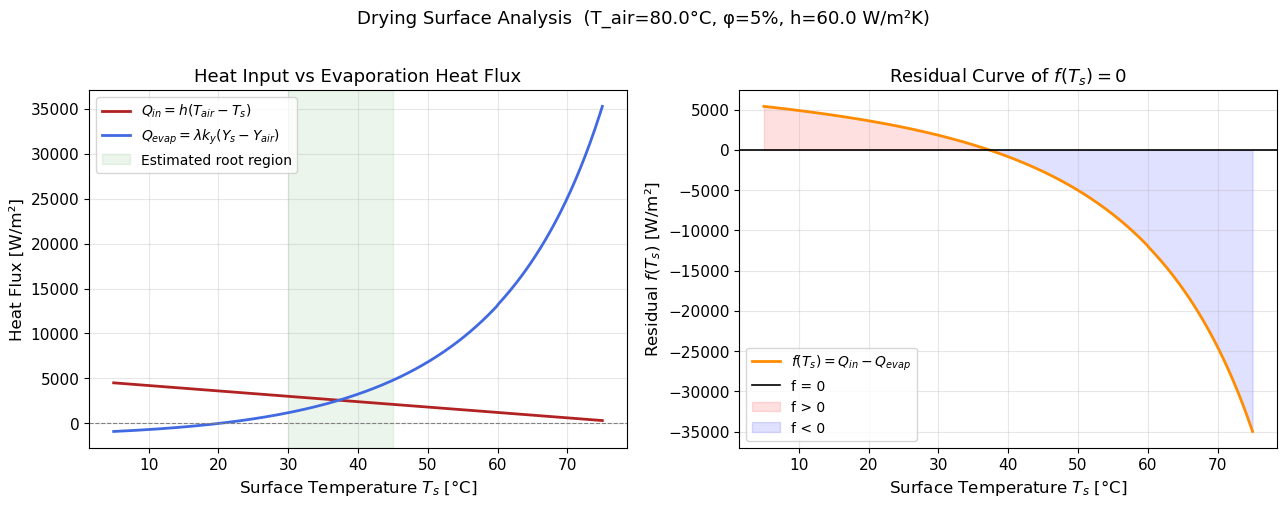


✓ 已儲存: d:\MyGit\ChemE-3502\Unit07\outputs\Unit07_Example_05\figs\fig_01_drying_analysis.png
  零點估算區間: [37.11, 37.28] °C


In [14]:
T_range = np.linspace(5, 75, 400)

Y_air_val = humidity_abs(T_air, phi=phi_air)
Q_in    = h * (T_air - T_range)
Q_evap  = lam_evap * k_y * (np.array([humidity_abs(T, 1.0) for T in T_range]) - Y_air_val)
f_vals  = Q_in - Q_evap

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# -- 左圖：熱傳 vs 蒸發曲線 --
ax = axes[0]
ax.plot(T_range, Q_in,   color='firebrick',    label=r'$Q_{in} = h(T_{air}-T_s)$')
ax.plot(T_range, Q_evap, color='royalblue',    label=r'$Q_{evap} = \lambda k_y (Y_s - Y_{air})$')
ax.axhline(0, color='gray', lw=0.8, ls='--')
# 標示交點區域
ax.axvspan(30, 45, alpha=0.08, color='green', label='Estimated root region')
ax.set_xlabel(r'Surface Temperature $T_s$ [°C]')
ax.set_ylabel('Heat Flux [W/m²]')
ax.set_title('Heat Input vs Evaporation Heat Flux')
ax.legend()

# -- 右圖：殘差曲線 f(T_s) --
ax2 = axes[1]
ax2.plot(T_range, f_vals, color='darkorange', label=r'$f(T_s) = Q_{in} - Q_{evap}$')
ax2.axhline(0, color='black', lw=1.2, ls='-', label='f = 0')
ax2.fill_between(T_range, f_vals, 0,
                 where=(f_vals > 0), alpha=0.12, color='red',   label='f > 0')
ax2.fill_between(T_range, f_vals, 0,
                 where=(f_vals < 0), alpha=0.12, color='blue',  label='f < 0')
ax2.set_xlabel(r'Surface Temperature $T_s$ [°C]')
ax2.set_ylabel(r'Residual $f(T_s)$ [W/m²]')
ax2.set_title(r'Residual Curve of $f(T_s) = 0$')
ax2.legend()

fig.suptitle(f'Drying Surface Analysis  (T_air={T_air}°C, φ={phi_air:.0%}, h={h} W/m²K)',
             fontsize=13, y=1.01)
fig.tight_layout()

fig_path = FIG_DIR / 'fig_01_drying_analysis.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ 已儲存: {fig_path}")

# 估算零點位置
sign_changes = np.where(np.diff(np.sign(f_vals)))[0]
for idx in sign_changes:
    print(f"  零點估算區間: [{T_range[idx]:.2f}, {T_range[idx+1]:.2f}] °C")

---
### 5. 數值求解：多方法比較

`scipy.optimize.root_scalar()` 提供多種求根方法，各有特性：

| 方法 | 類型 | 需要區間 | 需要導數 | 特性說明 |
|------|------|---------|---------|---------|
| `brentq` | 混合法 | ✅ 需要 | ❌ 不需 | Brent 法，最穩健，推薦首選 |
| `bisect` | 二分法 | ✅ 需要 | ❌ 不需 | 最安全但收斂最慢 |
| `newton` | Newton-Raphson | ❌ 不需 | ✅ 需要 | 最快，但需好的初始猜測值 |
| `secant` | 割線法 | ❌ 不需 | ❌ 不需 | 近似 Newton，需兩個初始點 |

由圖形分析確認：根位於 $[T_{low}, T_{high}]$ 之間，設定求解區間 `bracket=[25, 60]`。

In [15]:
bracket = [25.0, 60.0]   # 由圖形分析確定的求解區間

methods = [
    {'method': 'brentq',  'kwargs': {'bracket': bracket}},
    {'method': 'bisect',  'kwargs': {'bracket': bracket}},
    {'method': 'newton',  'kwargs': {'x0': 40.0}},
    {'method': 'secant',  'kwargs': {'x0': 35.0, 'x1': 45.0}},
]

print("=" * 72)
print(f"{'方法':<10} {'Ts (°C)':>12} {'殘差 f(Ts)':>16} {'迭代次數':>10} {'收斂':>8}")
print("=" * 72)

results = {}
for m in methods:
    try:
        sol = root_scalar(f_drying, method=m['method'], **m['kwargs'])
        T_sol  = sol.root
        resid  = f_drying(T_sol)
        nit    = sol.iterations if hasattr(sol, 'iterations') and sol.iterations else '—'
        conv   = '✓' if sol.converged else '✗'
        results[m['method']] = T_sol
        print(f"{m['method']:<10} {T_sol:>12.6f} {resid:>16.4e} {str(nit):>10} {conv:>8}")
    except Exception as e:
        print(f"{m['method']:<10} {'求解失敗':>36}  ({e})")

print("=" * 72)

# 選用 brentq 結果為最終答案
T_s_sol = results['brentq']
print(f"\n✓ 最終求解結果 (brentq): T_s = {T_s_sol:.4f} °C")

方法              Ts (°C)         殘差 f(Ts)       迭代次數       收斂
brentq        37.275156       8.6402e-12          9        ✓
bisect        37.275156       1.9509e-10         44        ✓
newton        37.275156      -1.3642e-12          4        ✓
secant        37.275156       8.6402e-12          6        ✓

✓ 最終求解結果 (brentq): T_s = 37.2752 °C


---
### 6. 乾燥速率計算與物理意義驗證

求得乾燥面溫度 $T_s^*$ 後，計算恆率乾燥速率 $N_A$ ：

$$
N_A = k_y \cdot (Y_s(T_s^*) - Y_{air}) \quad [\text{kg water/(m}^2\text{·s)}]
$$

**驗證方式（熱量守恆）：**

$$
\underbrace{h(T_{air} - T_s^*)}_{\text{熱傳速率 (W/m}^2\text{)}} = \underbrace{\lambda \cdot N_A}_{\text{蒸發耗熱 (W/m}^2\text{)}}
$$

若兩側差異極小（殘差 $\approx 0$ ），表示求解正確。

In [16]:
# ── 計算所有相關物理量 ─────────────────────────────────────
T_s       = T_s_sol
P_sat_Ts  = antoine_psat(T_s)
Y_s_val   = humidity_abs(T_s, phi=1.0)
Y_air_val = humidity_abs(T_air, phi=phi_air)

N_A       = k_y * (Y_s_val - Y_air_val)     # 乾燥速率 [kg/(m²·s)]
Q_heat    = h * (T_air - T_s)                # 熱傳速率 [W/m²]
Q_evap    = lam_evap * N_A                   # 蒸發耗熱 [W/m²]
residual  = Q_heat - Q_evap                  # 平衡殘差

print("=" * 55)
print("  乾燥面溫度計算結果")
print("=" * 55)
print(f"  乾燥面溫度    T_s        = {T_s:.4f} °C")
print(f"  飽和蒸氣壓    P_sat(Ts)  = {P_sat_Ts:.3f} mmHg")
print(f"  乾燥面絕對濕度 Y_s       = {Y_s_val:.5f} kg/kg")
print(f"  空氣絕對濕度   Y_air     = {Y_air_val:.5f} kg/kg")
print(f"  濕度差         ΔY        = {Y_s_val - Y_air_val:.5f} kg/kg")
print("-" * 55)
print(f"  恆率乾燥速率   N_A       = {N_A:.6f} kg/(m²·s)")
print(f"                           = {N_A*3600:.4f} kg/(m²·h)")
print("-" * 55)
print("  熱量平衡驗證:")
print(f"    熱傳速率  Q_in   = {Q_heat:.4f} W/m²")
print(f"    蒸發耗熱  Q_evap = {Q_evap:.4f} W/m²")
print(f"    平衡殘差  Δ      = {residual:.4e} W/m²  {'✓ 守恆' if abs(residual)<0.01 else '✗ 注意'}")
print("=" * 55)

  乾燥面溫度計算結果
  乾燥面溫度    T_s        = 37.2752 °C
  飽和蒸氣壓    P_sat(Ts)  = 47.662 mmHg
  乾燥面絕對濕度 Y_s       = 0.04161 kg/kg
  空氣絕對濕度   Y_air     = 0.01490 kg/kg
  濕度差         ΔY        = 0.02670 kg/kg
-------------------------------------------------------
  恆率乾燥速率   N_A       = 0.001068 kg/(m²·s)
                           = 3.8452 kg/(m²·h)
-------------------------------------------------------
  熱量平衡驗證:
    熱傳速率  Q_in   = 2563.4906 W/m²
    蒸發耗熱  Q_evap = 2563.4906 W/m²
    平衡殘差  Δ      = 8.1855e-12 W/m²  ✓ 守恆


---
### 7. 參數研究：乾燥空氣溫度的影響

固定其他參數，掃描乾燥空氣溫度 $T_{air}$ 從 50°C 到 130°C，觀察：

- **乾燥面溫度** $T_s^*$ 隨 $T_{air}$ 的變化趨勢
- **恆率乾燥速率** $N_A$ 隨 $T_{air}$ 的變化趨勢
- **溫差** $\Delta T = T_{air} - T_s^*$ 的變化

此分析對**乾燥機設計與操作條件最佳化**具有直接應用價值。

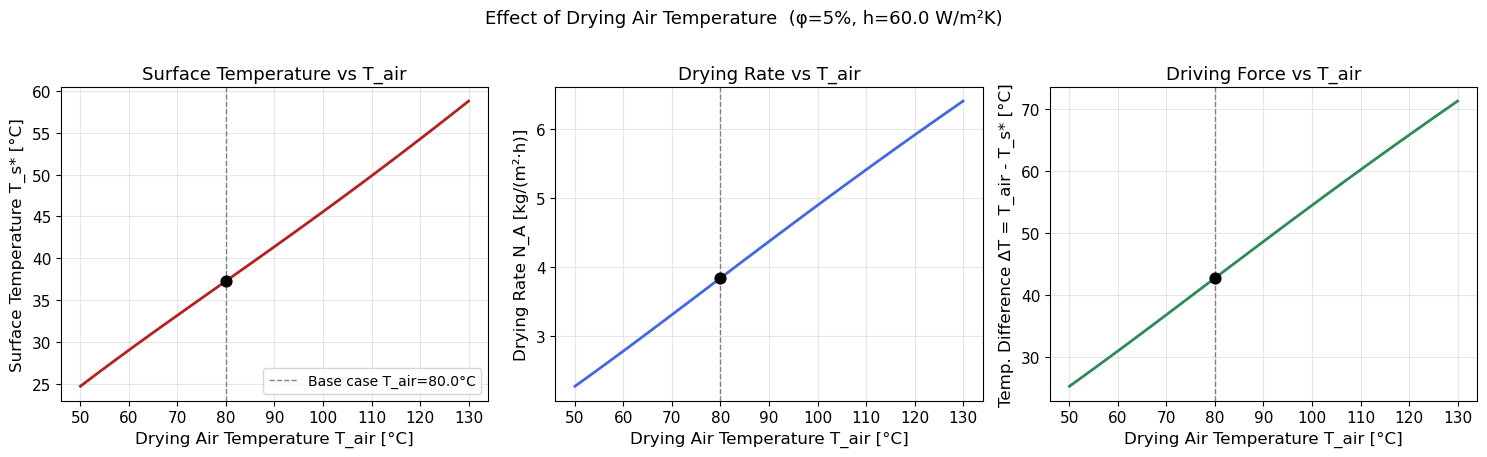

✓ 已儲存: d:\MyGit\ChemE-3502\Unit07\outputs\Unit07_Example_05\figs\fig_02_T_air_effect.png


In [19]:
T_air_range = np.linspace(50, 130, 80)
T_s_arr  = []
N_A_arr  = []
dT_arr   = []

for T_a in T_air_range:
    # 重新定義方程式（閉包帶入當前 T_a）
    def f_temp(Ts):
        Y_s   = humidity_abs(Ts, phi=1.0)
        Y_air_loc = humidity_abs(T_a, phi=phi_air)
        return h * (T_a - Ts) - lam_evap * k_y * (Y_s - Y_air_loc)

    try:
        # 上界限制在 95°C，避免 P_sat(Ts) > P_total 導致 humidity_abs 失效
        upper = min(T_a - 0.5, 95.0)
        sol = root_scalar(f_temp, method='brentq', bracket=[5.0, upper])
        T_s_i = sol.root
        Y_s_i   = humidity_abs(T_s_i, phi=1.0)
        Y_air_i = humidity_abs(T_a, phi=phi_air)
        N_A_i   = k_y * (Y_s_i - Y_air_i)
        T_s_arr.append(T_s_i)
        N_A_arr.append(N_A_i)
        dT_arr.append(T_a - T_s_i)
    except Exception:
        T_s_arr.append(np.nan)
        N_A_arr.append(np.nan)
        dT_arr.append(np.nan)

T_s_arr = np.array(T_s_arr)
N_A_arr = np.array(N_A_arr)
dT_arr  = np.array(dT_arr)

# ── 繪圖 ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].plot(T_air_range, T_s_arr, color='firebrick')
axes[0].axvline(T_air, color='gray', ls='--', lw=1, label=f'Base case T_air={T_air}°C')
axes[0].scatter([T_air], [T_s_sol], color='black', zorder=5, s=60)
axes[0].set_xlabel('Drying Air Temperature T_air [°C]')
axes[0].set_ylabel('Surface Temperature T_s* [°C]')
axes[0].set_title('Surface Temperature vs T_air')
axes[0].legend()

axes[1].plot(T_air_range, N_A_arr * 3600, color='royalblue')
axes[1].axvline(T_air, color='gray', ls='--', lw=1)
axes[1].scatter([T_air], [N_A * 3600], color='black', zorder=5, s=60)
axes[1].set_xlabel('Drying Air Temperature T_air [°C]')
axes[1].set_ylabel('Drying Rate N_A [kg/(m²·h)]')
axes[1].set_title('Drying Rate vs T_air')

axes[2].plot(T_air_range, dT_arr, color='seagreen')
axes[2].axvline(T_air, color='gray', ls='--', lw=1)
axes[2].scatter([T_air], [T_air - T_s_sol], color='black', zorder=5, s=60)
axes[2].set_xlabel('Drying Air Temperature T_air [°C]')
axes[2].set_ylabel('Temp. Difference ΔT = T_air - T_s* [°C]')
axes[2].set_title('Driving Force vs T_air')

fig.suptitle(f'Effect of Drying Air Temperature  (φ={phi_air:.0%}, h={h} W/m²K)',
             fontsize=13, y=1.01)
fig.tight_layout()

fig_path = FIG_DIR / 'fig_02_T_air_effect.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 已儲存: {fig_path}")


---
### 8. 參數研究：相對濕度的影響

固定 $T_{air} = 80°C$ ，掃描相對濕度 $\phi_{air}$ 從 0% 到 60%，分析：

- 相對濕度越高 → $Y_{air}$ 越高 → 濕度驅動力 $Y_s - Y_{air}$ 越小 → **乾燥速率下降**
- 乾燥面溫度 $T_s^*$ 隨相對濕度升高而**升高**（濕球效應減弱）

此分析反映**乾燥空氣品質（除濕程度）**對乾燥效率的重要性。

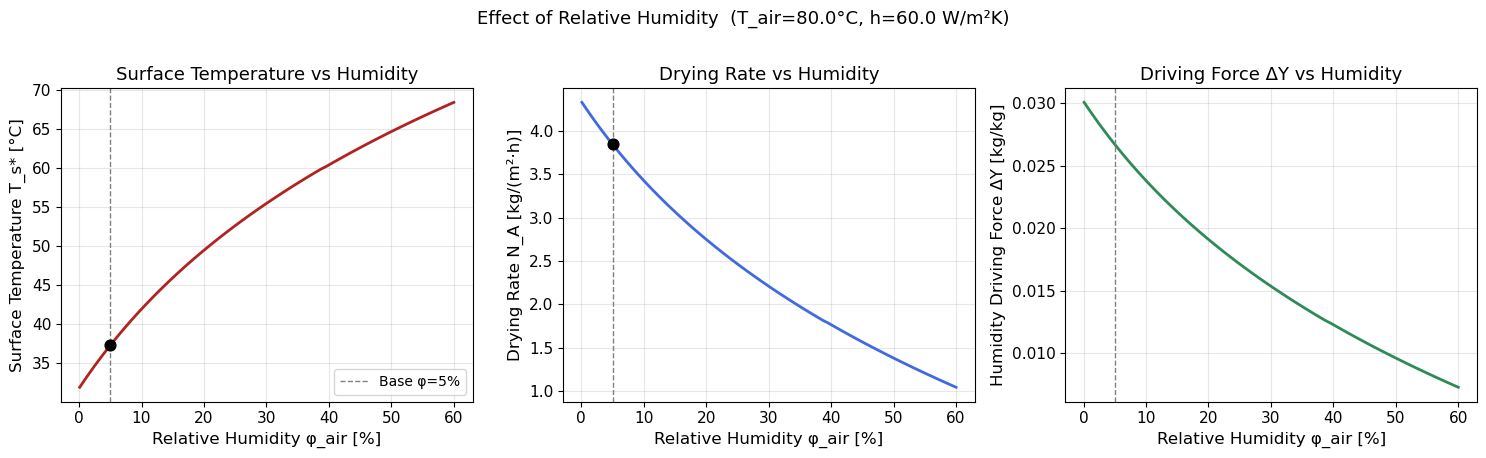

✓ 已儲存: d:\MyGit\ChemE-3502\Unit07\outputs\Unit07_Example_05\figs\fig_03_humidity_effect.png

相對濕度對乾燥速率影響摘要（T_air=80°C）：
  φ=10%: N_A = 3.4277 kg/(m²·h)
  φ=30%: N_A = 2.2101 kg/(m²·h)
  φ=50%: N_A = 1.3820 kg/(m²·h)


In [18]:
phi_range = np.linspace(0.001, 0.60, 80)
T_air_fix = 80.0   # 固定乾燥空氣溫度

T_s_phi  = []
N_A_phi  = []
dY_phi   = []

for phi_i in phi_range:
    def f_phi(Ts):
        Y_s_i    = humidity_abs(Ts, phi=1.0)
        Y_air_i  = humidity_abs(T_air_fix, phi=phi_i)
        return h * (T_air_fix - Ts) - lam_evap * k_y * (Y_s_i - Y_air_i)

    try:
        sol = root_scalar(f_phi, method='brentq', bracket=[5.0, T_air_fix - 0.5])
        Ts_i   = sol.root
        Y_s_i  = humidity_abs(Ts_i, phi=1.0)
        Y_ai   = humidity_abs(T_air_fix, phi=phi_i)
        T_s_phi.append(Ts_i)
        N_A_phi.append(k_y * (Y_s_i - Y_ai))
        dY_phi.append(Y_s_i - Y_ai)
    except Exception:
        T_s_phi.append(np.nan)
        N_A_phi.append(np.nan)
        dY_phi.append(np.nan)

T_s_phi = np.array(T_s_phi)
N_A_phi = np.array(N_A_phi)
dY_phi  = np.array(dY_phi)

# ── 繪圖 ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].plot(phi_range * 100, T_s_phi, color='firebrick')
axes[0].axvline(phi_air * 100, color='gray', ls='--', lw=1, label=f'Base φ={phi_air:.0%}')
axes[0].scatter([phi_air * 100], [T_s_sol], color='black', zorder=5, s=60)
axes[0].set_xlabel('Relative Humidity φ_air [%]')
axes[0].set_ylabel('Surface Temperature T_s* [°C]')
axes[0].set_title('Surface Temperature vs Humidity')
axes[0].legend()

axes[1].plot(phi_range * 100, N_A_phi * 3600, color='royalblue')
axes[1].axvline(phi_air * 100, color='gray', ls='--', lw=1)
axes[1].scatter([phi_air * 100], [N_A * 3600], color='black', zorder=5, s=60)
axes[1].set_xlabel('Relative Humidity φ_air [%]')
axes[1].set_ylabel('Drying Rate N_A [kg/(m²·h)]')
axes[1].set_title('Drying Rate vs Humidity')

axes[2].plot(phi_range * 100, dY_phi, color='seagreen')
axes[2].axvline(phi_air * 100, color='gray', ls='--', lw=1)
axes[2].set_xlabel('Relative Humidity φ_air [%]')
axes[2].set_ylabel('Humidity Driving Force ΔY [kg/kg]')
axes[2].set_title('Driving Force ΔY vs Humidity')

fig.suptitle(f'Effect of Relative Humidity  (T_air={T_air_fix}°C, h={h} W/m²K)',
             fontsize=13, y=1.01)
fig.tight_layout()

fig_path = FIG_DIR / 'fig_03_humidity_effect.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 已儲存: {fig_path}")

print()
print("相對濕度對乾燥速率影響摘要（T_air=80°C）：")
print(f"  φ=10%: N_A = {np.interp(0.10, phi_range, N_A_phi)*3600:.4f} kg/(m²·h)")
print(f"  φ=30%: N_A = {np.interp(0.30, phi_range, N_A_phi)*3600:.4f} kg/(m²·h)")
print(f"  φ=50%: N_A = {np.interp(0.50, phi_range, N_A_phi)*3600:.4f} kg/(m²·h)")

---
### 9. 總結

#### 求解流程回顧

| 步驟 | 操作 | 工具 |
|------|------|------|
| 1 | 建立熱質平衡方程式 $f(T_s)=0$ | 物理推導 |
| 2 | 計算飽和蒸氣壓（分段 Antoine） | `antoine_psat()` |
| 3 | 圖形法確認零點位置與求解區間 | `matplotlib` |
| 4 | 多方法數值求解比較 | `root_scalar()` |
| 5 | 驗證熱量守恆與計算乾燥速率 | 代回計算 |
| 6 | 參數研究（ $T_{air}$ 、 $\phi_{air}$ ） | 迴圈 + `root_scalar()` |

#### 計算結果彙整（基本工況）

| 物理量 | 數值 |
|--------|------|
| 乾燥空氣溫度 $T_{air}$ | 80.0 °C |
| 相對濕度 $\phi_{air}$ | 5% |
| **乾燥面溫度** $T_s^*$ | **37.2752 °C** |
| **恆率乾燥速率** $N_A$ | **1.068×10⁻³ kg/(m²·s)** |

#### 學習重點

1. **分段函數設計**：Antoine 方程式在不同溫度範圍使用不同係數，需以布林遮罩（Boolean Mask）實作分段邏輯，確保向量化運算正確且高效。
2. **圖形法輔助求解**：繪製 $f(T_s)$ 殘差曲線可快速確認解的存在性與位置，避免 `bracket` 設置不當導致求解失敗。
3. **多方法比較**：`brentq` 穩健性最佳（推薦）；`newton` 收斂最快但需合理初始值；`bisect` 最安全但收斂最慢。
4. **物理意義核實**：乾燥面溫度即「濕球溫度」，恆低於乾燥空氣溫度；相對濕度越高、 $T_{air}$ 越低，乾燥速率越小。